In [69]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import torch
import torch.optim
from flonacomldft.utils.data_utils import (
    load_from_pickle, load_zmat_csv, load_csv_file, get_path, 
)
from flonacomldft.internal_coordinates import get_mix_data
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.visualize import plotting_fes_db

from flonacomldft.internal_coordinates import Structure
from flonacomldft.collective_variables import get_CVs, compute_C, compute_R
# from flonacomldft.models import Uncentered_MLP
# from flonacomldft.mixture import Mixture, get_models
# from flonacomldft.dft_utils import Structure
# from flonacomldft.internal_coordinates import Angles_mapping

In [2]:
data_path = get_path()
data_path

'/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/'

In [3]:
data_is1 = load_zmat_csv("is1")
data_is2 = load_zmat_csv("is2")

xis, uis, cis = get_mix_data(data_is1, data_is2)

# Pretrain mlps and flows

# loading pretrain mlps models
mlp_is1 = load_from_pickle(get_path() + "mlp_is1")
mlp_is2 = load_from_pickle(get_path() + "mlp_is2")

# loading pretrain flows models
nf_is1 = load_from_pickle(get_path() + "training_is1")
nf_is2 = load_from_pickle(get_path() + "training_is2")

In [4]:
xis.shape, uis.shape, cis.shape

(torch.Size([10002, 12]), torch.Size([10002]), torch.Size([10002]))

<AxesSubplot:xlabel='Coordination Number', ylabel='Radius of Gyration [$\\mathrm{\\AA}$]'>

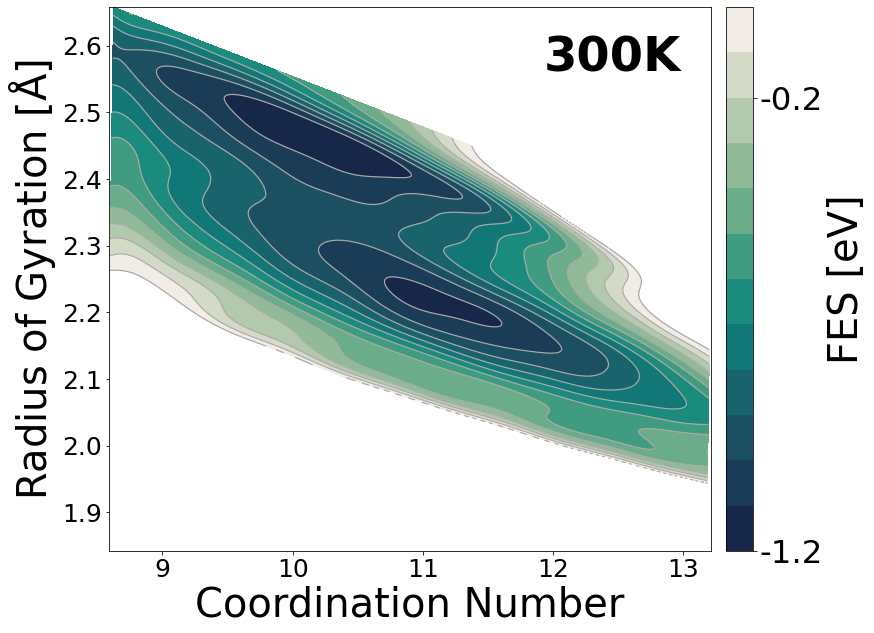

In [6]:
plotting_fes_db()

# Looking at the neighborhood of isomer 1 (= planar?)

In [99]:
n_steps = 10000

loss_fn = lambda x: mlp_is1.predict(x).sum()

# start_indx = -2
# # start_indx = -4
# assert cis[start_indx] == 0
# x = xis[start_indx].clone().requires_grad_(True)


x1s = xis[cis==0][-10:].clone().requires_grad_(True)

optimizer = torch.optim.Adam([x1s,], lr=1e-4)

energies = []
x_opt_s = []
for i in range(n_steps):
    optimizer.zero_grad()
    loss = loss_fn(x1s) 
    loss.backward()
    optimizer.step()
    energies.append(loss.item())
    x_opt_s.append(x1s.clone().detach())
x_opt_s = torch.stack(x_opt_s)
    

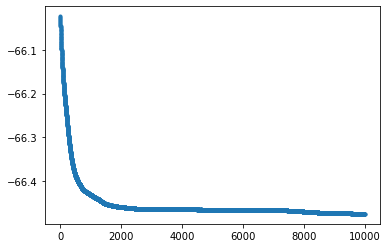

In [100]:
plt.plot(energies, '.-')

Final energies:  tensor([-6.6483, -6.6464, -6.6569, -6.6369, -6.6464, -6.6462, -6.6278, -6.6528,
        -6.6578, -6.6559])


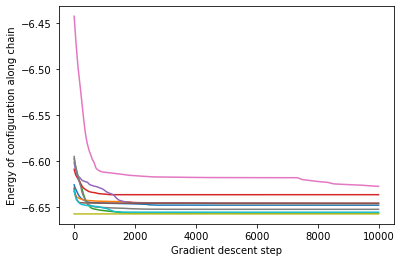

In [115]:
plt.plot(mlp_is1.predict(x_opt_s).detach().squeeze())
plt.xlabel("Gradient descent step")
plt.ylabel("Energy of configuration along chain")

print("Final energies: ", mlp_is1.predict(x_opt_s[-1]).detach().squeeze())

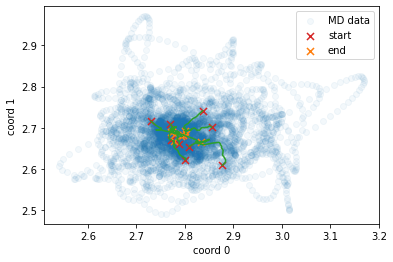

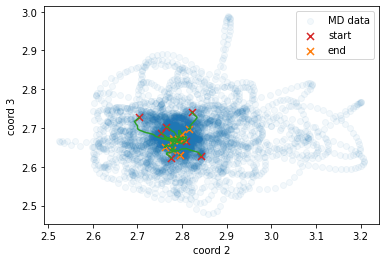

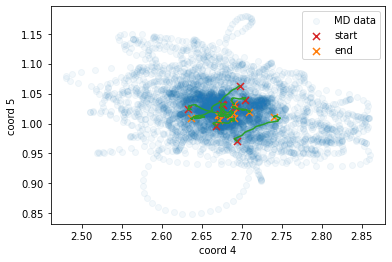

In [40]:
coord1 = 0
coord2 = 1

for (coord1, coord2) in [(0,1), (2,3), (4,5)]:
    plt.figure()
    plt.plot(x_opt_s[:, :, coord1], x_opt_s[:, :, coord2], '-', c='C2')
    plt.scatter(xis[cis==0, coord1], xis[cis==0, coord2], marker='o', color='C0', alpha=0.05,  label='MD data')
    plt.scatter(x_opt_s[0, :, coord1], x_opt_s[0, :, coord2], marker='x', color='C3', label='start', s=50)
    plt.scatter(x_opt_s[-1, :, coord1], x_opt_s[-1, :, coord2], marker='x', color='C1', label='end', s=50)
    plt.legend()
    plt.xlabel(f"coord {coord1}")
    plt.ylabel(f"coord {coord2}")


In [93]:

cvopt1s = np.array(get_CVs(x_opt_s[::1000].reshape(-1, 12))).T.reshape(-1, 10, 2)
cvopt1s.shape

(10, 10, 2)

(2.4, 2.55)

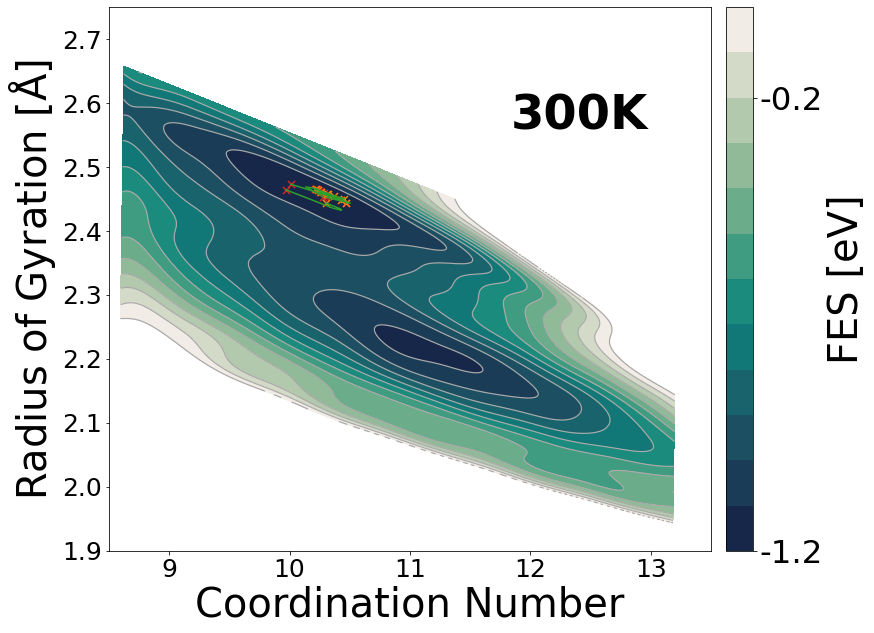

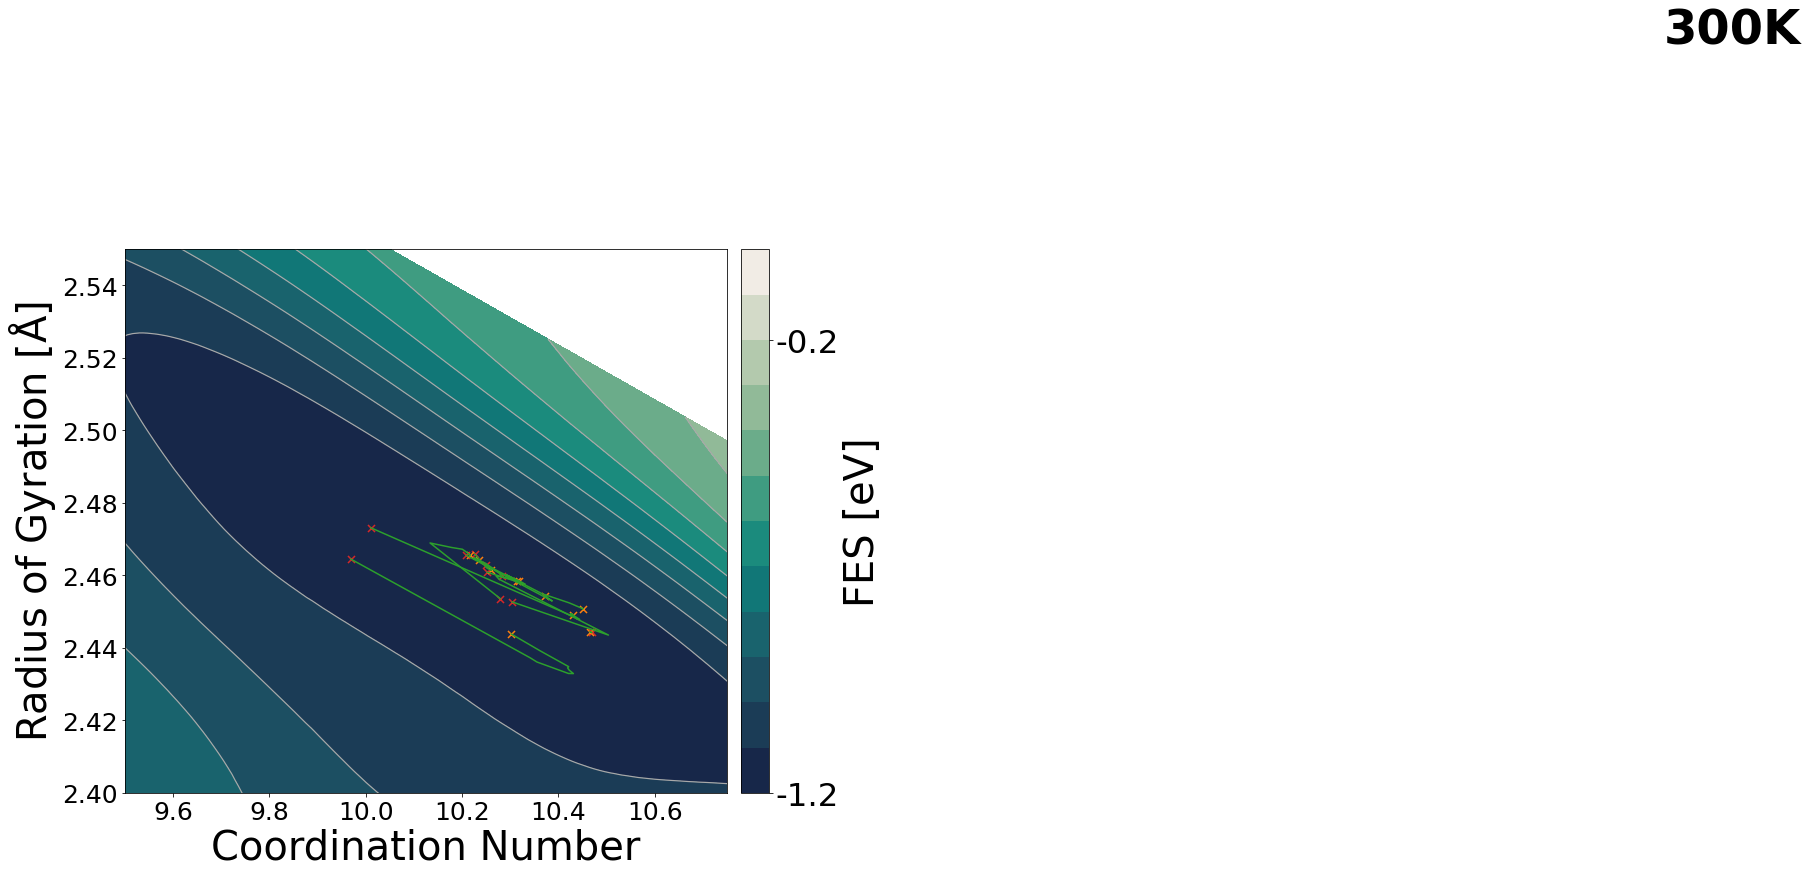

In [96]:
plotting_fes_db()
# cv1s = get_CVs(x1s.detach())
# plt.scatter(np.array(cv1s)[0, :], np.array(cv1s)[1,:], marker='x', color='C3', label='start', s=50)
plt.plot(cvopt1s[:, :, 0], cvopt1s[:, :, 1], '-', c='C2')
plt.scatter(cvopt1s[0, :, 0], cvopt1s[0, :, 1], marker='x', color='C3', label='start', s=50)
plt.scatter(cvopt1s[-1, :, 0], cvopt1s[-1, :, 1], marker='x', color='C1', label='end', s=50)
plt.xlim(8.5,13.5)
plt.ylim(1.9,2.75)

plotting_fes_db()
# cv1s = get_CVs(x1s.detach())
# plt.scatter(np.array(cv1s)[0, :], np.array(cv1s)[1,:], marker='x', color='C3', label='start', s=50)
plt.plot(cvopt1s[:, :, 0], cvopt1s[:, :, 1], '-', c='C2')
plt.scatter(cvopt1s[0, :, 0], cvopt1s[0, :, 1], marker='x', color='C3', label='start', s=50)
plt.scatter(cvopt1s[-1, :, 0], cvopt1s[-1, :, 1], marker='x', color='C1', label='end', s=50)
plt.xlim(9.5,10.75)
plt.ylim(2.4,2.55)
plt.legend()

# Same on isomer 2

In [117]:
n_steps = 10000

loss_fn = lambda x: mlp_is2.predict(x).sum()

# start_indx = -2
# # start_indx = -4
# assert cis[start_indx] == 0
# x = xis[start_indx].clone().requires_grad_(True)


x2s = xis[cis==1][-10:].clone().requires_grad_(True)

optimizer = torch.optim.Adam([x2s,], lr=1e-4)

energies = []
x_opt_s = []
for i in range(n_steps):
    optimizer.zero_grad()
    loss = loss_fn(x2s) 
    loss.backward()
    optimizer.step()
    energies.append(loss.item())
    x_opt_s.append(x2s.clone().detach())
x_opt_s = torch.stack(x_opt_s)
    

Final energies:  tensor([2.1469, 2.1267, 2.2954, 2.3235, 2.1940, 2.3291, 2.2153, 2.1469, 1.9711,
        2.2159])


Text(0, 0.5, 'Energy of configuration along chain')

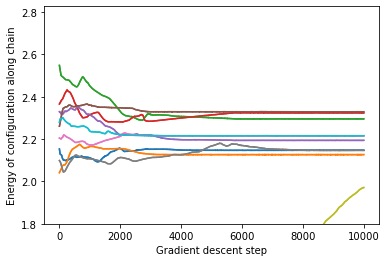

In [124]:
plt.plot(mlp_is1.predict(x_opt_s).detach().squeeze())
plt.xlabel("Gradient descent step")
plt.ylabel("Energy of configuration along chain")

print("Final energies: ", mlp_is1.predict(x_opt_s[-1]).detach().squeeze())

plt.plot(mlp_is1.predict(x_opt_s).detach().squeeze())
plt.ylim(1.8)
plt.xlabel("Gradient descent step")
plt.ylabel("Energy of configuration along chain")

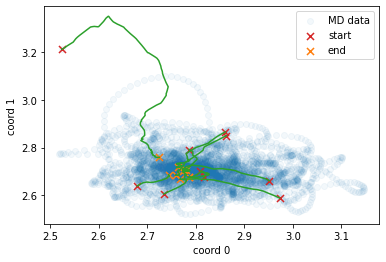

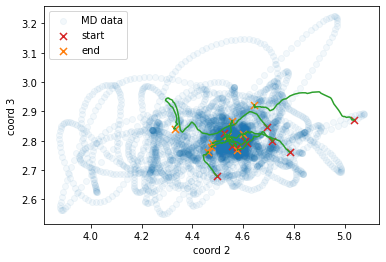

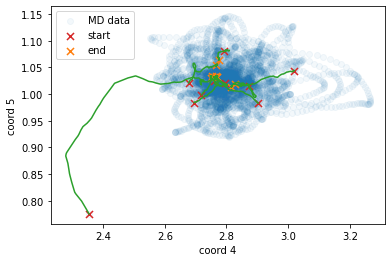

In [118]:
coord1 = 0
coord2 = 1

for (coord1, coord2) in [(0,1), (2,3), (4,5)]:
    plt.figure()
    plt.plot(x_opt_s[:, :, coord1], x_opt_s[:, :, coord2], '-', c='C2')
    plt.scatter(xis[cis==1, coord1], xis[cis==1, coord2], marker='o', color='C0', alpha=0.05,  label='MD data')
    plt.scatter(x_opt_s[0, :, coord1], x_opt_s[0, :, coord2], marker='x', color='C3', label='start', s=50)
    plt.scatter(x_opt_s[-1, :, coord1], x_opt_s[-1, :, coord2], marker='x', color='C1', label='end', s=50)
    plt.legend()
    plt.xlabel(f"coord {coord1}")
    plt.ylabel(f"coord {coord2}")


In [120]:
cvopt2s = np.array(get_CVs(x_opt_s[::1000].reshape(-1, 12))).T.reshape(-1, 10, 2)
cvopt2s.shape

(10, 10, 2)

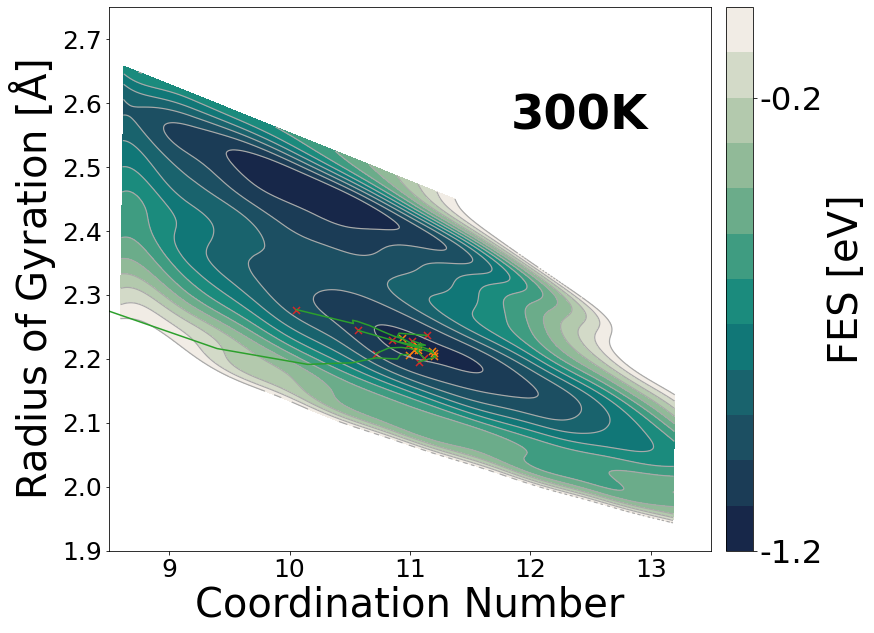

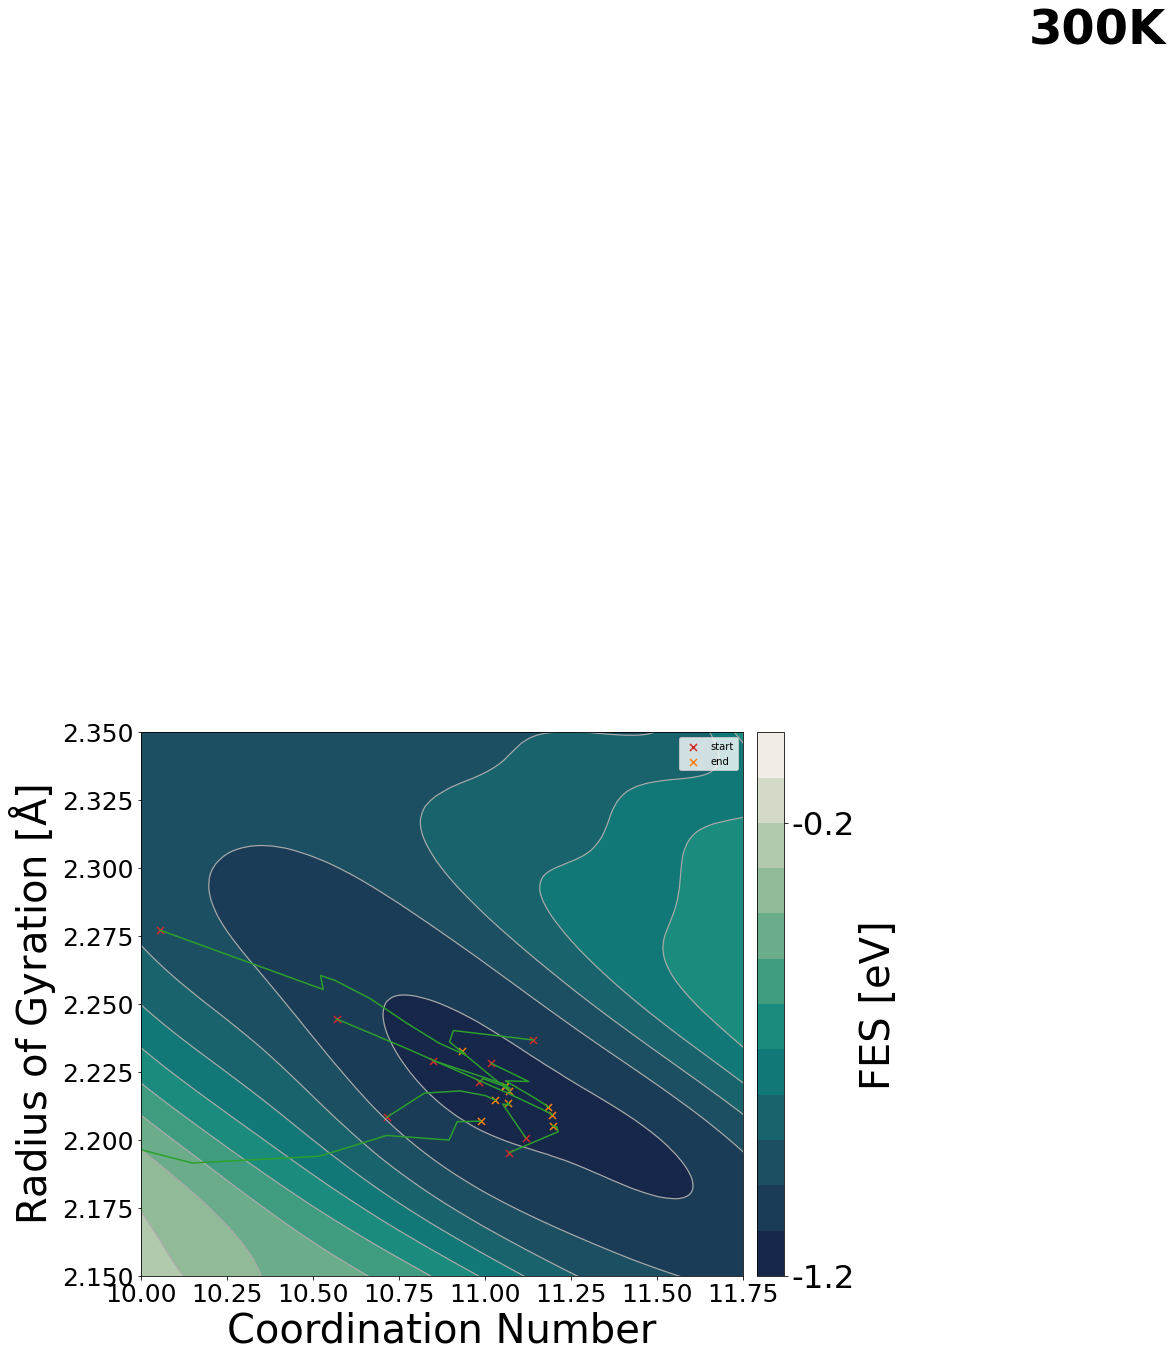

In [123]:
plotting_fes_db()
# cv1s = get_CVs(x1s.detach())
# plt.scatter(np.array(cv1s)[0, :], np.array(cv1s)[1,:], marker='x', color='C3', label='start', s=50)
plt.plot(cvopt2s[:, :, 0], cvopt2s[:, :, 1], '-', c='C2')
plt.scatter(cvopt2s[0, :, 0], cvopt2s[0, :, 1], marker='x', color='C3', label='start', s=50)
plt.scatter(cvopt2s[-1, :, 0], cvopt2s[-1, :, 1], marker='x', color='C1', label='end', s=50)
plt.xlim(8.5,13.5)
plt.ylim(1.9,2.75)

plotting_fes_db()
# cv1s = get_CVs(x1s.detach())
# plt.scatter(np.array(cv1s)[0, :], np.array(cv1s)[1,:], marker='x', color='C3', label='start', s=50)
plt.plot(cvopt2s[:, :, 0], cvopt2s[:, :, 1], '-', c='C2')
plt.scatter(cvopt2s[0, :, 0], cvopt2s[0, :, 1], marker='x', color='C3', label='start', s=50)
plt.scatter(cvopt2s[-1, :, 0], cvopt2s[-1, :, 1], marker='x', color='C1', label='end', s=50)
plt.xlim(10,11.75)
plt.ylim(2.15,2.35)
plt.legend()